In [1]:
import sys, os

ML_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
SRC_DIR = os.path.join(ML_ROOT, "src")
sys.path.insert(0, ML_ROOT)
sys.path.insert(0, SRC_DIR)

import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
import importlib
import config, model as model_mod, train as train_mod
importlib.reload(config); importlib.reload(model_mod); importlib.reload(train_mod)

from model import build_model
from train import train
from dataset import DermaSenseDataset
from utils import set_seed

set_seed(config.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")
print(f"GPU     : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
import importlib
import train as train_mod
importlib.reload(train_mod)
from train import train
print("✅ train.py reloaded")

Device  : cuda
GPU     : NVIDIA GeForce RTX 3050 6GB Laptop GPU
✅ train.py reloaded


In [2]:
PROC = config.DATA_PROCESSED

train_df = pd.read_csv(os.path.join(PROC, "train.csv"))
val_df   = pd.read_csv(os.path.join(PROC, "val.csv"))

with open(os.path.join(PROC, "label2idx.json")) as f:
    l2i = json.load(f)
with open(os.path.join(PROC, "idx2label.json")) as f:
    i2l = {int(k): v for k, v in json.load(f).items()}

class_weights  = np.load(os.path.join(PROC, "class_weights.npy"))
sample_weights = np.load(os.path.join(PROC, "sample_weights.npy"))

config.NUM_CLASSES = len(l2i)

print(f"Train    : {len(train_df)} | Val : {len(val_df)}")
print(f"Classes  : {config.NUM_CLASSES}")
print(f"Weights  : min={class_weights.min():.3f} max={class_weights.max():.3f}")

Train    : 3694 | Val : 653
Classes  : 181
Weights  : min=0.310 max=1.701


In [3]:
EXTRA_DIRS = [config.DATASET_DIR_0, config.DATASET_DIR_1]

train_ds = DermaSenseDataset(
    train_df, config.DATASET_DIR_0, l2i,
    config.IMG_COL, config.LABEL_COL,
    config.IMG_SIZE, train=True, extra_dirs=EXTRA_DIRS
)
val_ds = DermaSenseDataset(
    val_df, config.DATASET_DIR_0, l2i,
    config.IMG_COL, config.LABEL_COL,
    config.IMG_SIZE, train=False, extra_dirs=EXTRA_DIRS
)

sampler = WeightedRandomSampler(
    weights     = torch.tensor(sample_weights, dtype=torch.float32),
    num_samples = len(sample_weights),
    replacement = True
)

train_loader = DataLoader(
    train_ds, batch_size=config.BATCH_SIZE,
    sampler=sampler, num_workers=0, pin_memory=False
)
val_loader = DataLoader(
    val_ds, batch_size=config.BATCH_SIZE,
    shuffle=False, num_workers=0, pin_memory=False
)

# Quick batch check
imgs, tabs, labels = next(iter(train_loader))
print(f"Batch — Images: {imgs.shape} | Tabular: {tabs.shape} | Labels: {labels.shape}")
print("✅ DataLoaders ready")

Batch — Images: torch.Size([24, 3, 300, 300]) | Tabular: torch.Size([24, 96]) | Labels: torch.Size([24])
✅ DataLoaders ready


In [4]:
net = build_model(
    num_classes = config.NUM_CLASSES,
    tabular_dim = config.TABULAR_DIM,
    fusion_dim  = config.FUSION_DIM,
    dropout     = config.DROPOUT,
    pretrained  = True,
).to(device)

total     = sum(p.numel() for p in net.parameters())
trainable = sum(p.numel() for p in net.parameters() if p.requires_grad)
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
print("✅ Model ready")

Total params    : 11,227,997
Trainable params: 11,227,997
✅ Model ready


In [5]:
history = train(
    model        = net,
    train_loader = train_loader,
    val_loader   = val_loader,
    config       = config,
    device       = device,
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
)


  Training DermaSense — 181 classes
  Epochs: 40 | Batch: 24 | LR: 0.0003
  Device: cuda



Epoch 001/40 | T_loss: 5.5368  T_acc: 0.0084  T_top5: 0.0417 | V_loss: 5.5995  V_acc: 0.0357  V_top5: 0.1027 | LR: 3.00e-05  [913s]
  ✅ Best model saved (val_acc=0.0357)


Epoch 002/40 | T_loss: 5.2391  T_acc: 0.0869  T_top5: 0.2109 | V_loss: 5.1494  V_acc: 0.2649  V_top5: 0.4583 | LR: 8.40e-05  [955s]
  ✅ Best model saved (val_acc=0.2649)


Epoch 003/40 | T_loss: 4.7269  T_acc: 0.2266  T_top5: 0.4402 | V_loss: 4.6489  V_acc: 0.3423  V_top5: 0.6182 | LR: 1.38e-04  [1506s]
  ✅ Best model saved (val_acc=0.3423)


Epoch 004/40 | T_loss: 4.1595  T_acc: 0.3286  T_top5: 0.5994 | V_loss: 4.3778  V_acc: 0.3821  V_top5: 0.6688 | LR: 1.92e-04  [1552s]
  ✅ Best model saved (val_acc=0.3821)


...

Epoch 036/40 | T_loss: 1.3719  T_acc: 0.9843  T_top5: 0.9978 | V_loss: 3.2090  V_acc: 0.6330  V_top5: 0.8622 | LR: 1.77e-05  [1955s]


Epoch 037/40 | T_loss: 1.3547  T_acc: 0.9857  T_top5: 0.9984 | V_loss: 3.2127  V_acc: 0.6271  V_top5: 0.8533 | LR: 1.25e-05  [1951s]


Epoch 038/40 | T_loss: 1.3838  T_acc: 0.9873  T_top5: 0.9976 | V_loss: 3.2234  V_acc: 0.6390  V_top5: 0.8429 | LR: 8.35e-06  [1644s]


Epoch 039/40 | T_loss: 1.3843  T_acc: 0.9862  T_top5: 0.9976 | V_loss: 3.2154  V_acc: 0.6301  V_top5: 0.8518 | LR: 5.39e-06  [1942s]


Epoch 040/40 | T_loss: 1.3595  T_acc: 0.9889  T_top5: 0.9981 | V_loss: 3.2133  V_acc: 0.6271  V_top5: 0.8604 | LR: 3.60e-06  [1785s]

  Training complete. Best Val Acc: 0.6390



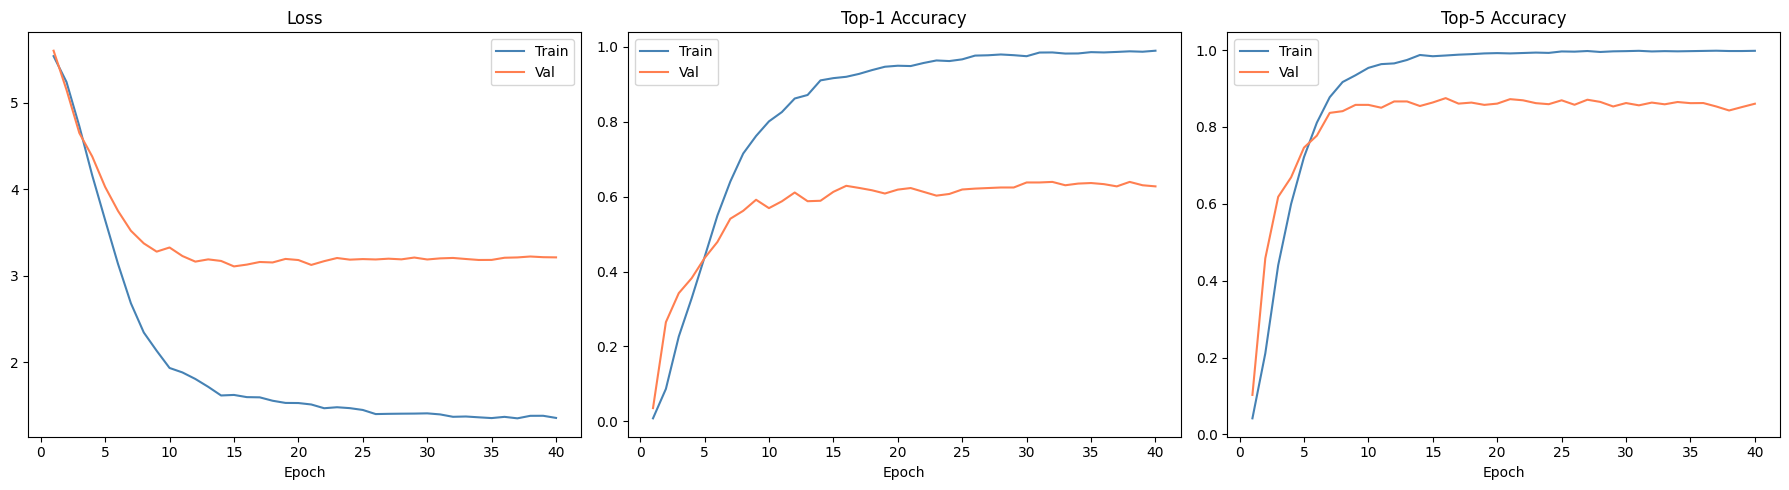


Best Val Acc  : 0.6390 @ Epoch 32
Best Val Top5 : 0.8750


In [6]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs, history["train_loss"], label="Train", color="steelblue")
axes[0].plot(epochs, history["val_loss"],   label="Val",   color="coral")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

# Top-1 Accuracy
axes[1].plot(epochs, history["train_acc"], label="Train", color="steelblue")
axes[1].plot(epochs, history["val_acc"],   label="Val",   color="coral")
axes[1].set_title("Top-1 Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")

# Top-5 Accuracy
axes[2].plot(epochs, history["train_top5"], label="Train", color="steelblue")
axes[2].plot(epochs, history["val_top5"],   label="Val",   color="coral")
axes[2].set_title("Top-5 Accuracy"); axes[2].legend(); axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig(f"{config.PLOTS_DIR}/training_curves.png", dpi=150)
plt.show()

best_epoch = history["val_acc"].index(max(history["val_acc"])) + 1
print(f"\nBest Val Acc  : {max(history['val_acc']):.4f} @ Epoch {best_epoch}")
print(f"Best Val Top5 : {max(history['val_top5']):.4f}")